# Exam

First let's import the data and see what we have

In [1]:
import numpy as np
import  pandas as pd 

df = pd.read_csv("data/depression.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


**id** doesn't have any meaningful data for prediction that's why I will drop it.

In [2]:
df = df.drop('id', axis=1)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  object 
 1   Age                                    27901 non-null  float64
 2   City                                   27901 non-null  object 
 3   Profession                             27901 non-null  object 
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA                                   27901 non-null  float64
 7   Study Satisfaction                     27901 non-null  float64
 8   Job Satisfaction                       27901 non-null  float64
 9   Sleep Duration                         27901 non-null  object 
 10  Dietary Habits                         27901 non-null  object 
 11  De

I wanted to see all the columns that have dtype object.
 
These 
Gender, City, Profession, Sleep Duration, Dietary Habits, Degree, Have you ever had suicidal thoughts ?, Financial Stress, Family History of Mental Illness.

In [4]:
df.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


<Axes: >

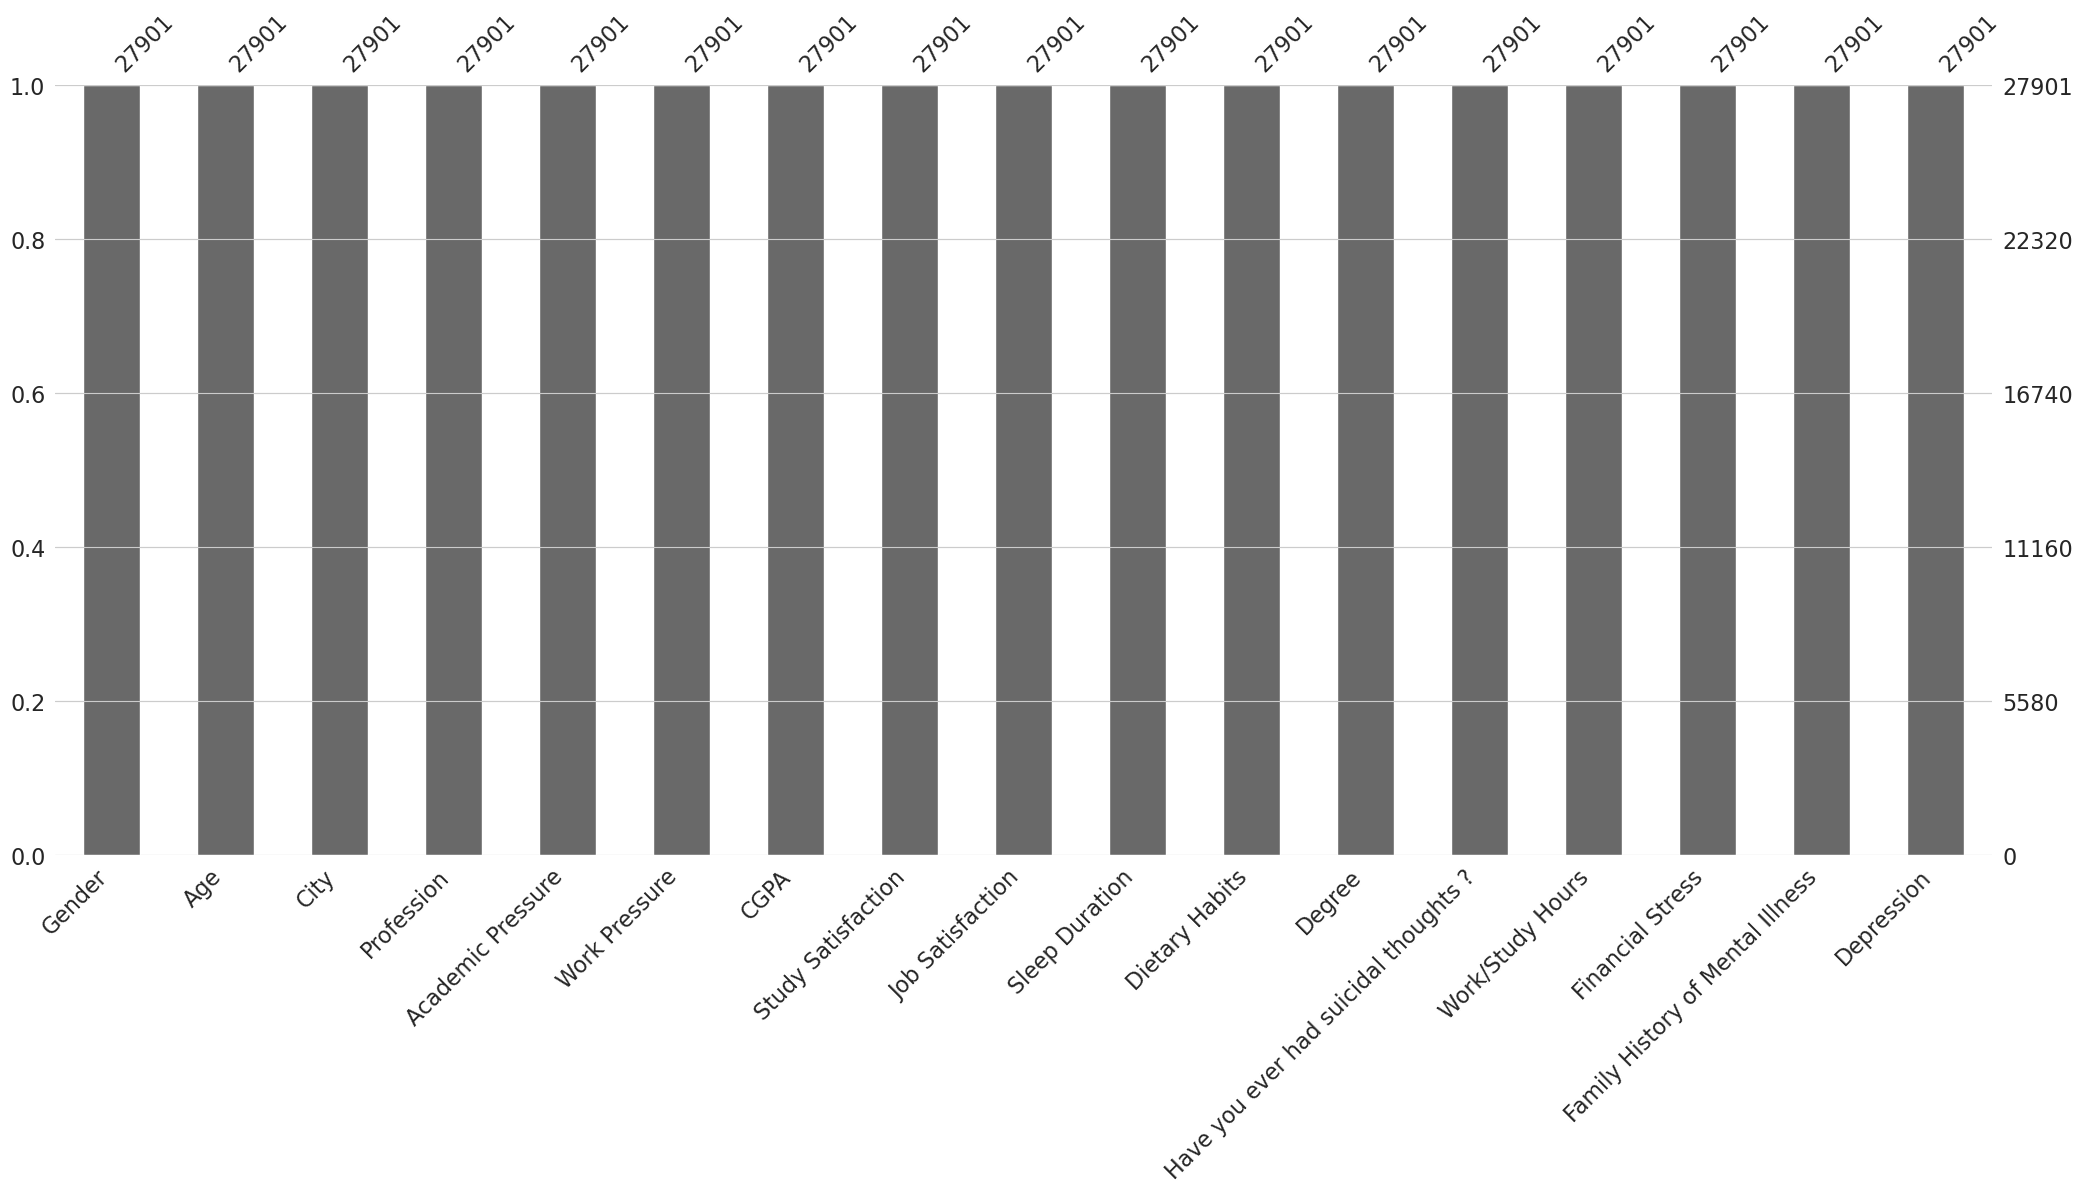

In [5]:
import missingno as msno
%matplotlib inline
msno.bar(df)

From this chart we can see that there aren't NaN values in dataset. 

post-scriptum: we will find values that are filled with 0 or "Others" instead of NaN values

In [6]:
columns_for_plotting = df.select_dtypes(include=['int', 'float']).columns
columns_for_plotting

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Depression'],
      dtype='object')

Here are the features with numerical values.

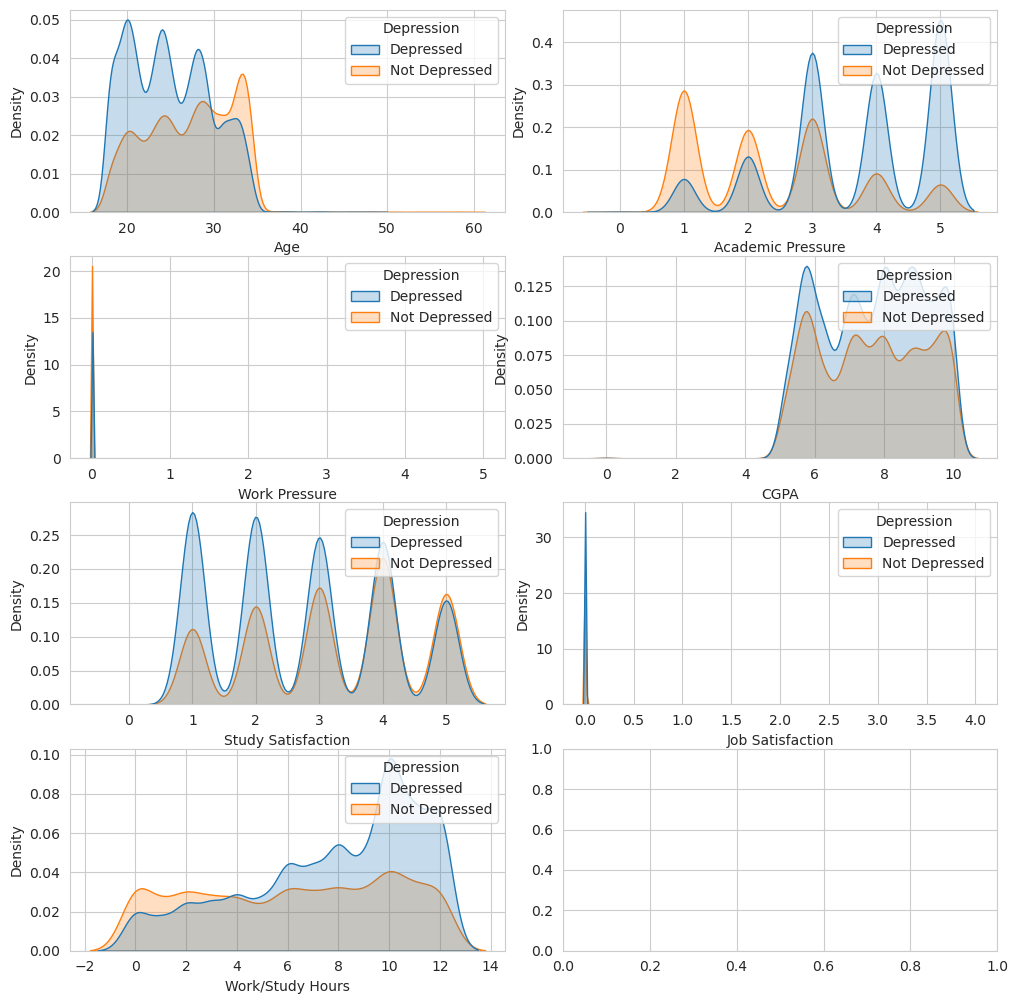

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns

columns_for_plotting = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours','Depression']
fig, axes = plt.subplots(4, 2, figsize=(10, 10))
fig.tight_layout() 

category = df.copy() 
category["Depression"] = category["Depression"].astype(str) # a warning raises if the 
category.loc[category["Depression"] == "1", "Depression"] = "Depressed"
category.loc[category["Depression"] == "0", "Depression"]  = "Not Depressed"

axes = axes.flatten()
with sns.axes_style("whitegrid"):
    for i, column in enumerate(pd.DataFrame(columns=columns_for_plotting).drop('Depression', axis=1)):
        sns.kdeplot(category, x=column , hue="Depression", fill=True, ax = axes[i])

Let's draw some conclusions from these charts. Firstly we could observe that the **Age** will have a bigger negative correlation factor with Depression also this could be said about **Study Satisfaction** too. But also we can observe another two features that have a bigger correlation factor **Academic Pressure** and **Work/Study Hours**. 

From **Work Pressure** and **Job Satisfaction** graphs I assume that there are values different from 0, but they are so few that I consider to drop features that are related to jobs. (work pressure, job satisfaction)

In [8]:
category.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,Depressed
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,Not Depressed
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,Not Depressed
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,Depressed
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,Not Depressed


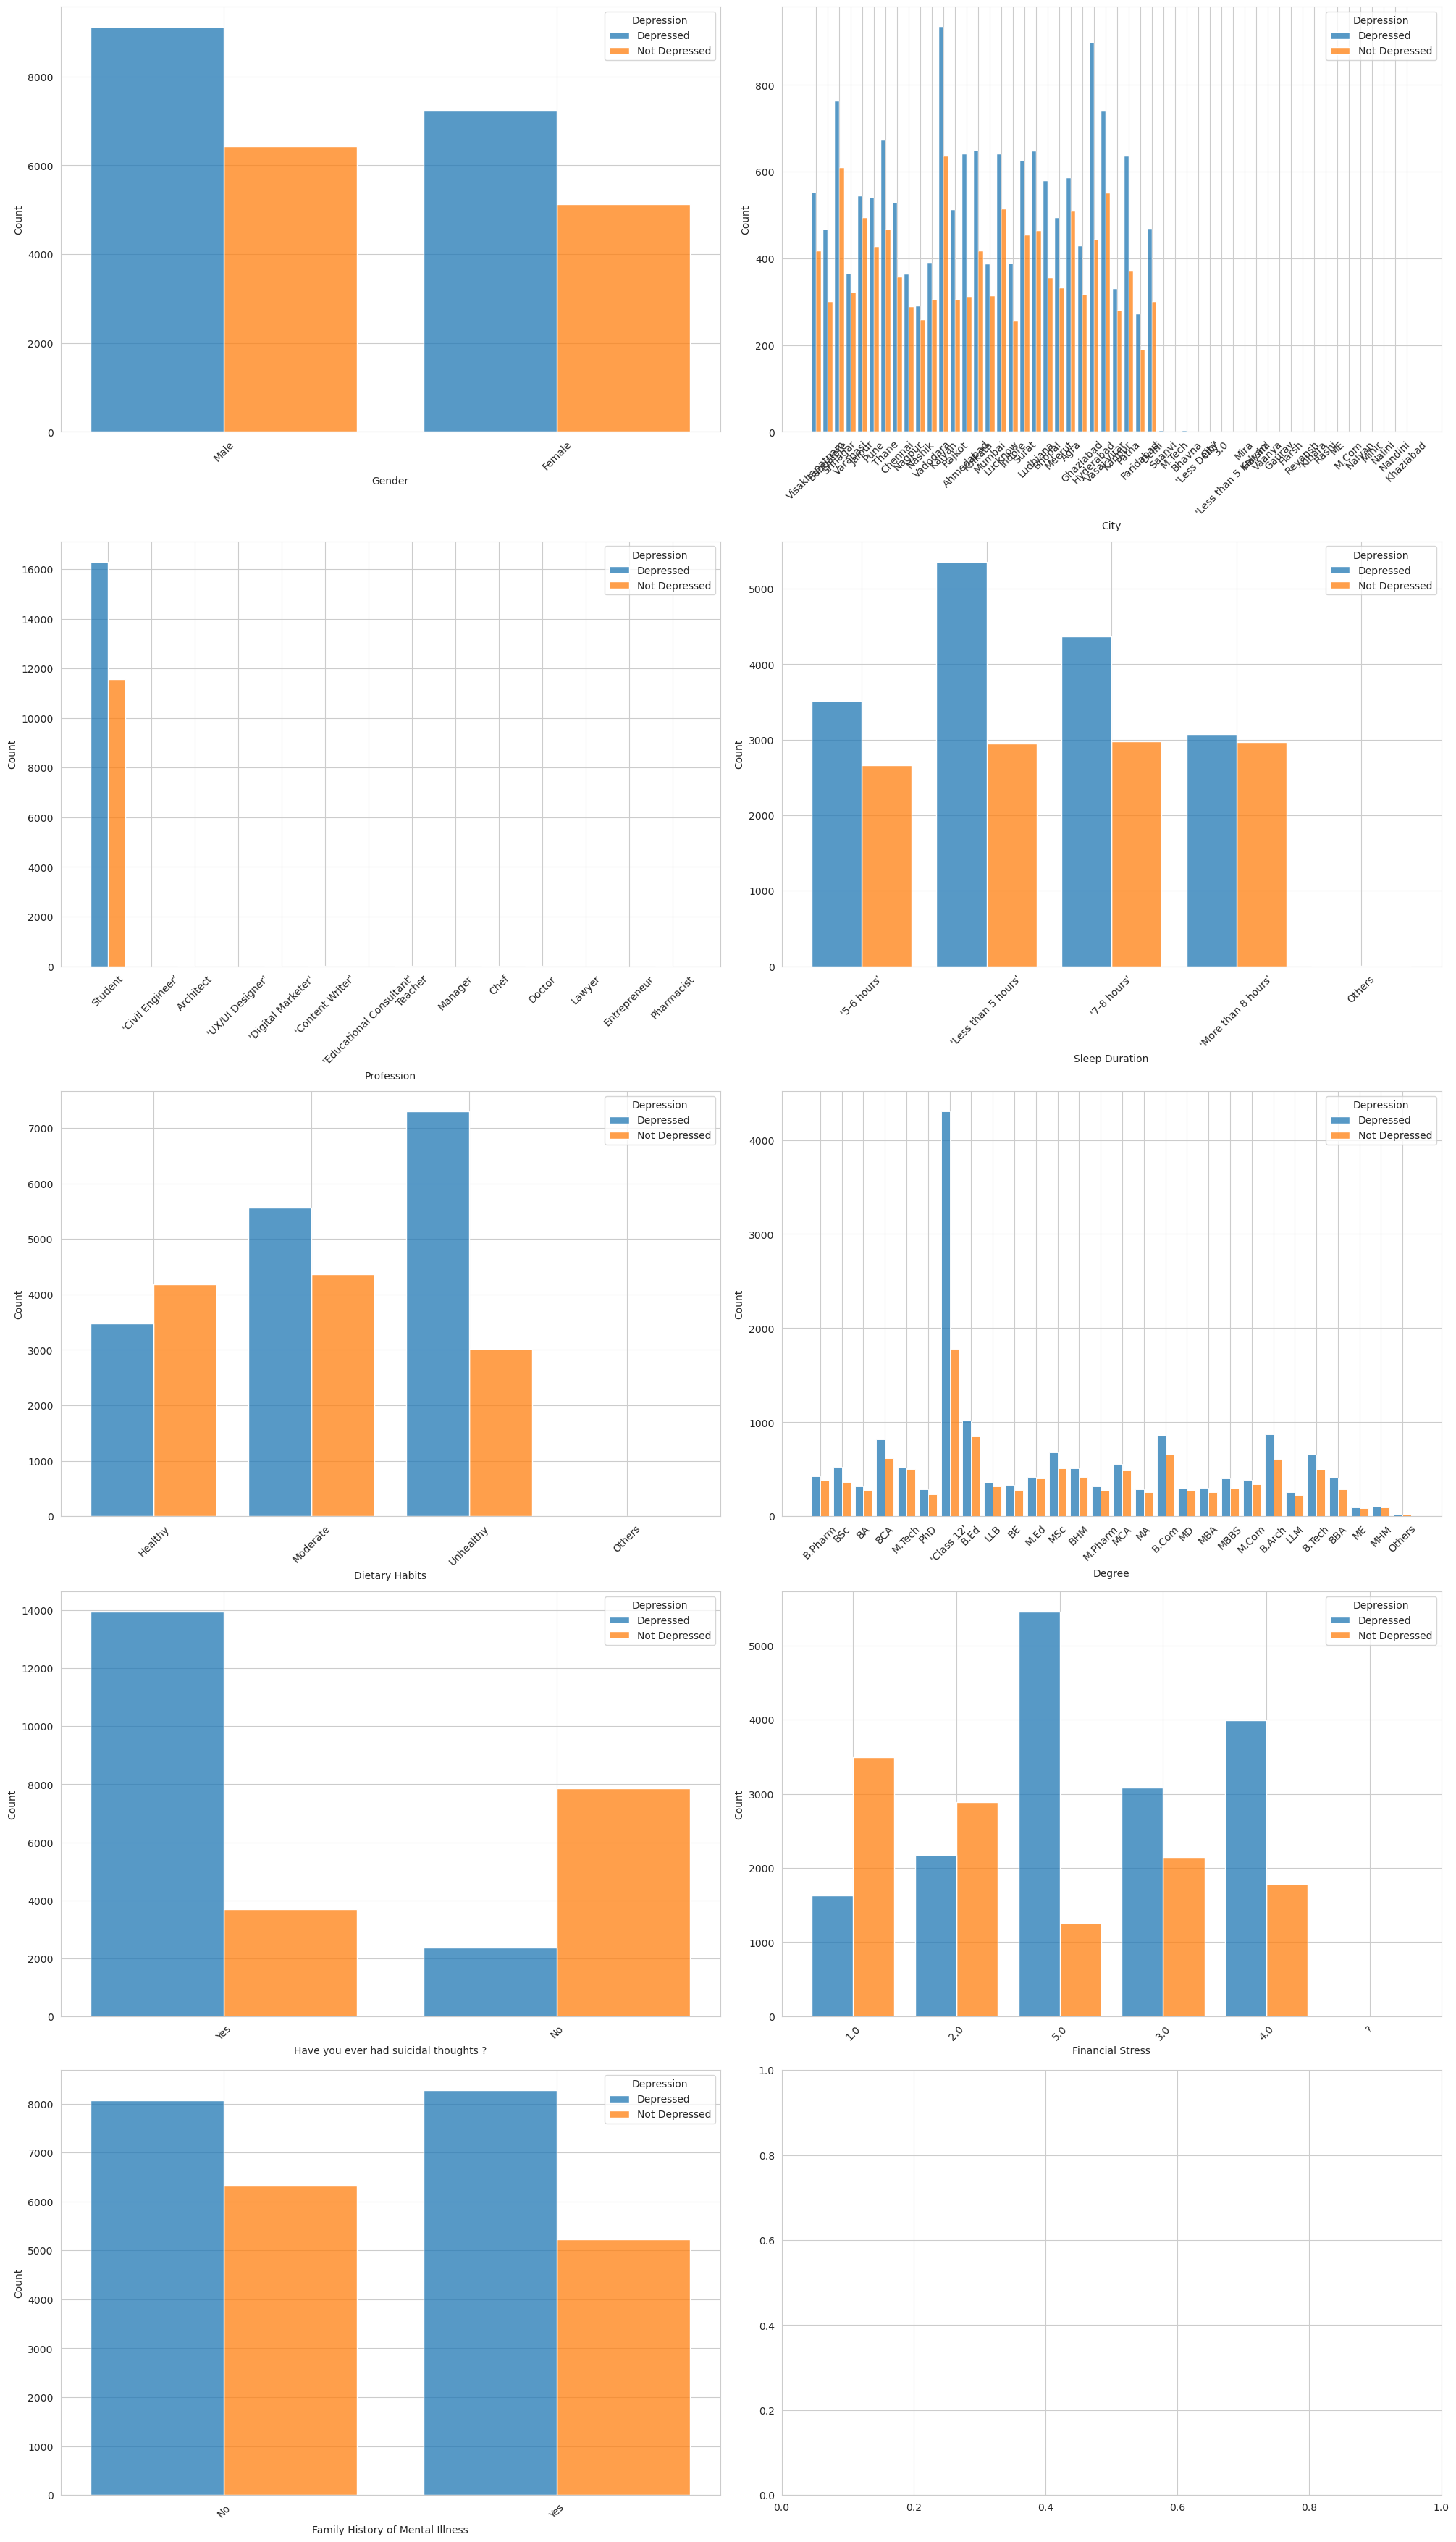

In [9]:
import seaborn as sns


fig, axes = plt.subplots(5, 2, figsize=(20, 35), constrained_layout=True)
axes = axes.flatten()
# fig.tight_layout() 

category = df.drop(columns_for_plotting[:-1], axis=1).copy() 
category["Depression"] = category["Depression"].astype(str) # a warning raises if the 
category.loc[category["Depression"] == "1", "Depression"] = "Depressed"
category.loc[category["Depression"] == "0", "Depression"]  = "Not Depressed"

for i, column in enumerate(category.columns[:-1]):
    ax =  sns.histplot( data=category, x=column, hue="Depression", multiple="dodge", ax=axes[i], shrink=.8)
    ax.tick_params(axis='x', labelrotation = 45)

Here I want to point out:
- As mentioned above I consider to remove all features related to the jobs, because we could se here also that the most significant value of Profession is Student which is irrelevant therefor I will remove anything related to job (**Work Pressure**, **Profession** and **Job Satisfaction**).
- Also, we could see that causes of the depression are intuitive for example we see that there is an increase in nr of Depressed people that sleep lesser hours have unhealthy dietary habits had suicidal thoughts and have a high financial stress. 

In [10]:
df = df.drop(["Work Pressure", "Profession", "Job Satisfaction"], axis=1)

In [11]:
len(df.loc[df["Financial Stress"] == "?"])

3

In [12]:
len(df.loc[df["Sleep Duration"] == "Others"])

18

In [13]:
len(df.loc[df["Dietary Habits"] == "Others"])

12

There are few values of "Others" and "?" therefor to not complicate my self I will just delete them.

In [14]:
df = df.loc[df["Financial Stress"] != "?"]
df = df.loc[df["Sleep Duration"] != "Others"]
df = df.loc[df["Dietary Habits"] != "Others"]

Now I would like to transform data into numeric values. 


Here I could apply dummy variables for **Gender**, **Have you ever had suicidal thoughts?**, **Family History of Mental illness**, but I prefer Label Encoder because it gives me more control and obtain the same result also I could reuse it for other columns.
Here is another thing I feel I need to explain, why did I apply label encoding for values like **Dietary Habits**? I did it because the labels behind are just some increasing ratings.

In [15]:
from sklearn.preprocessing import LabelEncoder

labels = {
    "Gender" : ["Female", "Male"], # 0, 1
    "Have you ever had suicidal thoughts ?": ["No", "Yes"], # 0, 1
    "Family History of Mental Illness": ["No", "Yes"], # 0, 1
    "Financial Stress": ['1.0', '2.0', '3.0', '4.0', '5.0'], # 0, 1, 2, 3, 4
    "Dietary Habits" : ["Unhealthy", "Moderate", "Healthy"], # 0, 1, 2
}

for column, feature_values in labels.items():
    label_encoder = LabelEncoder()
    label_encoder.fit(feature_values)
    df[column] = label_encoder.transform(df[column])

Now I would like to assign for each label of sleep hours a rank. where 'more than 8 hours' will be a 10, 'lesser than 5' a 1,  '7-8 hours' will be 8, '5-6 hours will be a 10'. How did establish this values? (intuition, and my own experience of sleep)

In [16]:
df.loc[:,"Sleep Duration"].unique()

array(["'5-6 hours'", "'Less than 5 hours'", "'7-8 hours'",
       "'More than 8 hours'"], dtype=object)

In [17]:

sleep_labels = {
    "'Less than 5 hours'":1,
    "'5-6 hours'": 5,
    "'7-8 hours'":8,
    "'More than 8 hours'":10
}

for label, value in sleep_labels.items():
    df.loc[df["Sleep Duration"] == label, 'Sleep Duration'] = value

In [18]:
df.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,Visakhapatnam,5.0,8.97,2.0,5,0,B.Pharm,1,3.0,0,0,1
1,0,24.0,Bangalore,2.0,5.90,5.0,5,1,BSc,0,3.0,1,1,0
2,1,31.0,Srinagar,3.0,7.03,5.0,1,0,BA,0,9.0,0,1,0
3,0,28.0,Varanasi,3.0,5.59,2.0,8,1,BCA,1,4.0,4,1,1
4,0,25.0,Jaipur,4.0,8.13,3.0,5,1,M.Tech,1,1.0,0,0,0


Now for the cities, I will do something new for me. 

In [19]:
all_cities = df.City.unique()
all_cities

array(['Visakhapatnam', 'Bangalore', 'Srinagar', 'Varanasi', 'Jaipur',
       'Pune', 'Thane', 'Chennai', 'Nagpur', 'Nashik', 'Vadodara',
       'Kalyan', 'Rajkot', 'Ahmedabad', 'Kolkata', 'Mumbai', 'Lucknow',
       'Indore', 'Surat', 'Ludhiana', 'Bhopal', 'Meerut', 'Agra',
       'Ghaziabad', 'Hyderabad', 'Vasai-Virar', 'Kanpur', 'Patna',
       'Faridabad', 'Delhi', 'Saanvi', 'M.Tech', 'Bhavna', "'Less Delhi'",
       'City', '3.0', "'Less than 5 Kalyan'", 'Mira', 'Harsha', 'Vaanya',
       'Gaurav', 'Harsh', 'Reyansh', 'Kibara', 'Rashi', 'ME', 'M.Com',
       'Nalyan', 'Mihir', 'Nalini', 'Nandini', 'Khaziabad'], dtype=object)

So I did some chitchatting with the claude and found out that not all this values are actually cities. For example "City" or "3.0". These values are probably miss imputations.

In [20]:
real_indian_cities = [
    'Visakhapatnam',
    'Bangalore',
    'Srinagar',
    'Varanasi',
    'Jaipur',
    'Pune',
    'Thane',
    'Chennai',
    'Nagpur',
    'Nashik',
    'Vadodara',
    'Kalyan',
    'Rajkot',
    'Ahmedabad',
    'Kolkata',
    'Mumbai',
    'Lucknow',
    'Indore',
    'Surat',
    'Ludhiana',
    'Bhopal',
    'Meerut',
    'Agra',
    'Ghaziabad',
    'Hyderabad',
    'Vasai-Virar',
    'Kanpur',
    'Patna',
    'Faridabad',
    'Delhi'
]

"Khaziabad" this value I know that is a misspelled. There are probably more misspelling cities but i am not an expert in indian cities therefor I will remove other values that are not actual cities.

In [21]:
df.loc[df["City"] == "Khaziabad", 'City'] = "Ghaziabad"
for city in all_cities:
    df = df.loc[df["City"].isin(real_indian_cities)]       

Here a wise move would be to creat a some sort of ranking of cities and to assign the rank instead of city, unfortunately I didn't find on internet a complete list that will help me that's why I asked Gemini to create research for ranking the quality of living in these cities. To be honest I doubt the results, but again I am not an indian specialist but for now I will assume results are true.

the prompt (Gemini Deep Research):
```
can you assign a rank for each of this cities:
[
'Visakhapatnam',
'Bangalore',
'Srinagar',
'Varanasi',
'Jaipur',
'Pune',
'Thane',
'Chennai',
'Nagpur',
'Nashik',
'Vadodara',
'Kalyan',
'Rajkot',
'Ahmedabad',
'Kolkata',
'Mumbai',
'Lucknow',
'Indore',
'Surat',
'Ludhiana',
'Bhopal',
'Meerut',
'Agra',
'Ghaziabad',
'Hyderabad',
'Vasai-Virar',
'Kanpur',
'Patna',
'Faridabad',
'Delhi'
]
the rank in based on quality of living
(1) Search for recent reports or surveys on the quality of living in major cities in India.
(2) For each city in the provided list, find information on factors contributing to the quality of living, such as safety, healthcare, education, and infrastructure.
(3) Investigate the environmental quality of each city, including air and water pollution levels and the availability of green spaces.
(4) Research the economic opportunities and job market conditions in each city.
(5) Find information on the cost of living in each city, including housing, transportation, and daily expenses.
(6) Explore the cultural and recreational amenities available in each city.
(7) Based on the gathered information, create a quality of living index for each city, considering the relative importance of the factors.
(8) Compare the calculated index values for each city.
(9) Based on the comparison of the index values, assign a rank to each city in the provided list, from highest to lowest quality of living.
```
Here are the results:

In [22]:
ranking_cities = pd.read_csv("data/india_cities_ranking_living.csv")
ranking_cities = ranking_cities.drop(["Rank", "Brief Highlights of Strengths and Weaknesses"], axis=1)
ranking_cities

,City,Index Score
0,Hyderabad,4.0
1,Pune,3.9
2,Bangalore,3.8
3,Chennai,3.7
4,Ahmedabad,3.6
5,Kolkata,3.5
6,Mumbai,3.4
7,Visakhapatnam,3.2
8,Nashik,3.0
9,Vadodara,3.0


[ Varanasi, Jaipur, Nagpur, Lucknow, Indore, Surat] these are values that don't have any information therefor we will assign a score of 1.

In [23]:
ranking_cities = pd.concat([
    ranking_cities,
    pd.DataFrame({
        "City": [ "Varanasi", "Jaipur", "Nagpur", "Lucknow", "Indore", "Surat"],
        "Index Score": [1, 1, 1, 1, 1, 1],
    }),
],ignore_index=True)

In [24]:
ranking_cities

,City,Index Score
0,Hyderabad,4.0
1,Pune,3.9
2,Bangalore,3.8
3,Chennai,3.7
4,Ahmedabad,3.6
5,Kolkata,3.5
6,Mumbai,3.4
7,Visakhapatnam,3.2
8,Nashik,3.0
9,Vadodara,3.0


In [25]:
for index, row in ranking_cities.iterrows():
    city = row['City']
    score = row["Index Score"]
    df.loc[df["City"] == city, 'City'] = score 

I discovered now that I skipped **Degrees**. I could proceed the same as with the cities finding the fulfilment for every degree in internet assign a score and then to proceed to training but as seen before in the graphs there is a big portion of students that are only in High School which makes an unbalanced dataset therefor....

In [26]:
df.Degree.unique()

array(['B.Pharm', 'BSc', 'BA', 'BCA', 'M.Tech', 'PhD', "'Class 12'",
       'B.Ed', 'LLB', 'BE', 'M.Ed', 'MSc', 'BHM', 'M.Pharm', 'MCA', 'MA',
       'B.Com', 'MD', 'MBA', 'MBBS', 'M.Com', 'B.Arch', 'LLM', 'B.Tech',
       'BBA', 'ME', 'MHM', 'Others'], dtype=object)

I will group them by HighSchool, Bachelor, Master and PhD. (btw I assumed that all the values that begins with M are master and the ones that starts with B are bachelors)

In [27]:
masters = ['M.Tech','MSc', 'M.Pharm', 'MCA', 'MA', 'MD', 'MBA', 'MBBS', 'M.Com',  'LLM','ME', 'MHM', "M.Ed"]
bachelors = ['B.Pharm', 'BSc', 'BA', 'BCA', 'B.Ed', 'LLB', 'BE','BHM', 'B.Com', 'B.Arch', 'B.Tech', 'BBA']

for degree in masters:
    df.loc[df.Degree == degree, "Degree"] = "Master"
for degree in bachelors:
    df.loc[df.Degree == degree, "Degree"] = "Bachelor"

In [28]:
df.Degree.unique()

array(['Bachelor', 'Master', 'PhD', "'Class 12'", 'Others'], dtype=object)

In [29]:
len(df.loc[df["Degree"] == "Others"])

35

This is a good opportunity to show an example of imputing data.

In [30]:
df.loc[df["Degree"] == "Others", "Degree"] = np.NaN

In [31]:
from  sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[["'Class 12'", 'Bachelor', 'Master', 'PhD', np.nan]], unknown_value=np.nan, handle_unknown="use_encoded_value")
df.Degree = encoder.fit_transform(df["Degree"].values.reshape(-1,1))

Now I will apply KNNImputer for the nan values I created earlier instead of the "Others".

In [32]:
from sklearn.impute import KNNImputer

imputed_df = KNNImputer().fit_transform(df)
df = pd.DataFrame(imputed_df, columns=df.columns)

In [33]:
df.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1.0,33.0,3.2,5.0,8.97,2.0,5.0,0.0,1.0,1.0,3.0,0.0,0.0,1.0
1,0.0,24.0,3.8,2.0,5.90,5.0,5.0,1.0,1.0,0.0,3.0,1.0,1.0,0.0
2,1.0,31.0,2.1,3.0,7.03,5.0,1.0,0.0,1.0,0.0,9.0,0.0,1.0,0.0
3,0.0,28.0,1.0,3.0,5.59,2.0,8.0,1.0,1.0,1.0,4.0,4.0,1.0,1.0
4,0.0,25.0,1.0,4.0,8.13,3.0,5.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0


Now I would plot some box-plots to identify if we have outliers. (plots will be only for  columns that were initially numerical continues values)

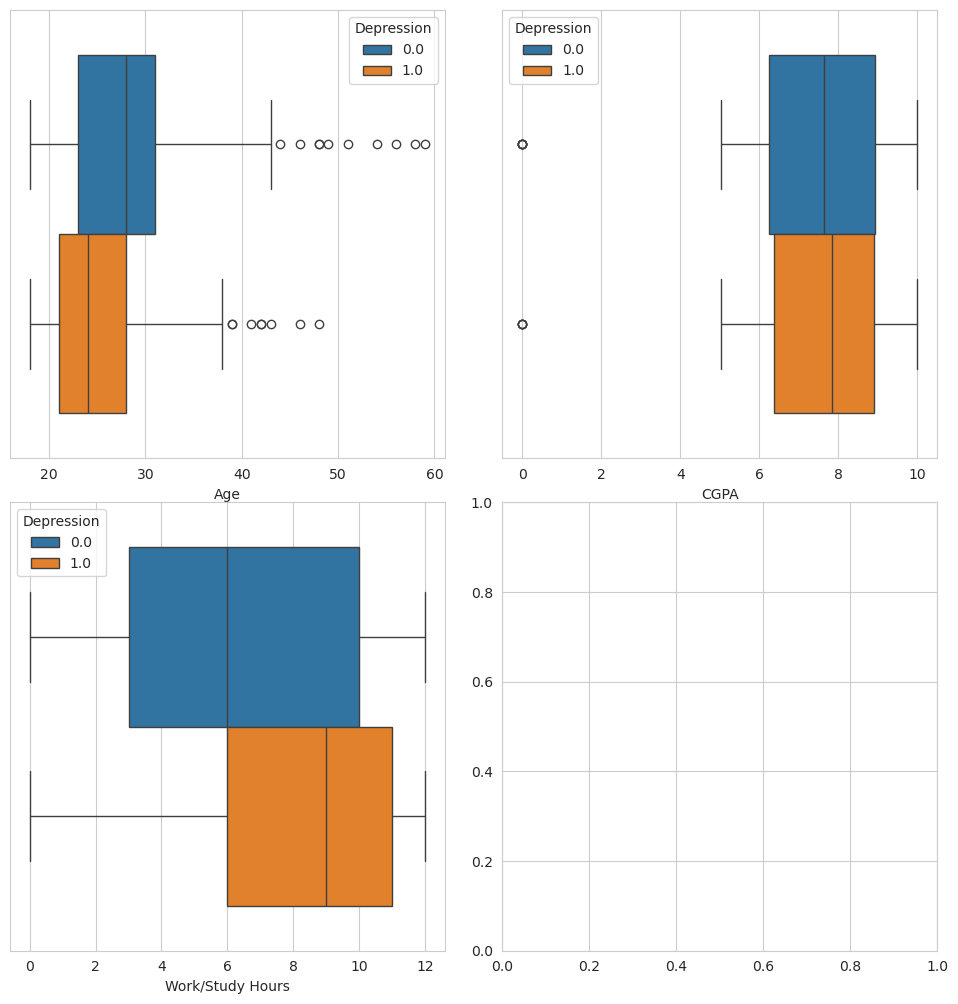

In [34]:
from matplotlib import pyplot as plt
import seaborn as sns

columns_for_plotting = ['Age', 'CGPA', 'Work/Study Hours','Depression']
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.tight_layout() 

category = df.copy() 

axes = axes.flatten()
with sns.axes_style("whitegrid"):
    for i, column in enumerate(pd.DataFrame(columns=columns_for_plotting).drop('Depression', axis=1)):
        sns.boxplot(category, x=column , hue="Depression", fill=True, ax = axes[i])

We could see that there are some outliers for **Age** and **CGPA,** but they are few therefore the contamination level is low ~0.001.(a number identified experimentally by comparing the nr of bullets in the graphs and nr of outliers found)

In [35]:
from sklearn.ensemble import IsolationForest

model=IsolationForest(contamination=0.001)
df['outlier']=pd.Series(model.fit_predict(df.values))
outlier_counts = len(df[df.outlier==-1])
df=df[df.outlier!=-1]
df.drop(['outlier'], axis=1, inplace=True)

In [36]:
outlier_counts

28

And with that I finished data preparation. We fully cleaned and prepared the dataset for training. 

In [38]:
df.to_csv("data/students_depression_prepared.csv", index=False)